In [1]:
import pandas as pd
import os
import sys
import json
import copy

import geojson
from shapely import Polygon

project_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_dir)

from src.io import *
from src.geometry import *
from src.utils import *
from src.viz import *
from src.core import *
from src.tests import *

In [ ]:
region = 'contiguous/world'
level = 'original_world'
year = 2016
region = 'india'
level = 'states'
year = '2015-16'
# region = 'usa'
# level = 'states'
year = 2016
# region = 'taiwan'
# level = 'states'
year = 2016

In [3]:
data, polygons, target_areas, target_positions, names, centroid = loader(region, level, year="2015-16")
region_names = [k for k in data if k != "__meta__"]
polygons = []
polygons = [np.asarray(data[name]["polygon"]) for name in region_names]

Matched name column: 'NAME_1', value column: 'gdp'
Number of unmatched regions for year 2015-16: 0


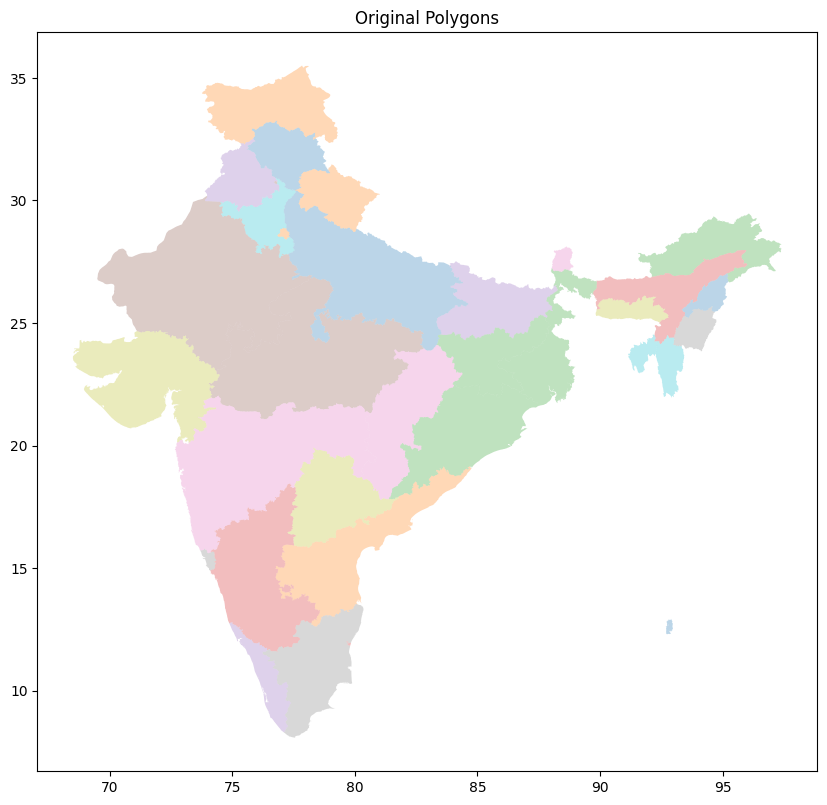

In [4]:
plot_polys_data(data, title="Original Polygons", centroids=False, legend=False, target_centers=None)

In [5]:
horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical_center(polygons)

In [6]:
fixed_points = [np.mean(p, axis=0) for p in polygons]
neighbours   = neighbouring_pairs(polygons)
shared_verts = shared_vertices_of_neighbors(polygons)

Contiguous mode 'square': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 33.9928


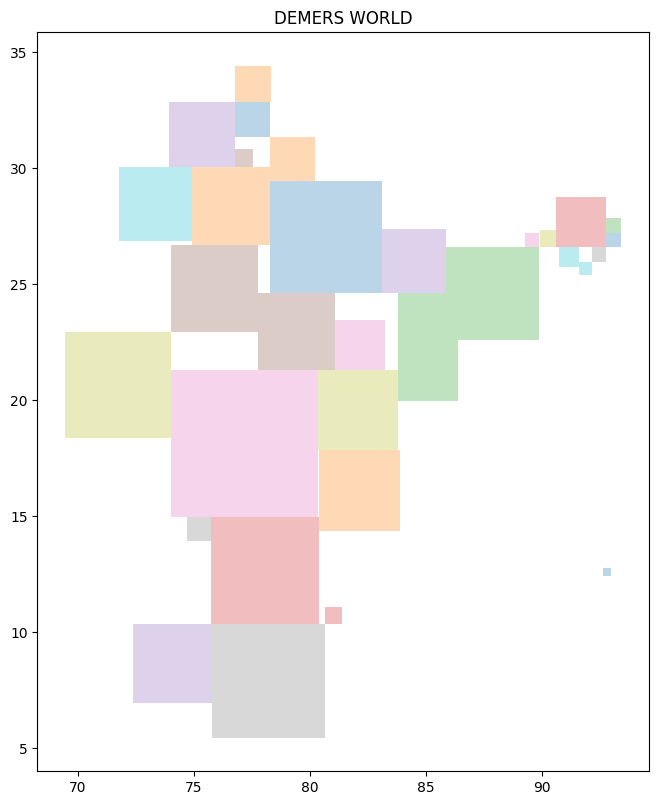

In [7]:
# DEMERS
new_data = CartogramFramework_global(
        data,
        # polygons=polygons,
        # target_areas=target_areas,
        fixed_points=None,             # → uses polygon centroids as origins
        shape="square",             # "circle", "square", or "contiguous"
        target_centers=target_positions,
        horizontal_pairs=horizontal_pairs,
        vertical_pairs=vertical_pairs,
        neighboring_pairs=neighbouring_pairs(polygons),
        shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),

        lambda_shape=0.1,    # small; E_square ≈ 0 once squares are pre-built # Demers: 0.1
        lambda_area=1.0,      # Demers 1.0
        lambda_center=0.0,    # TOP variant (Fig. 1 left) — purely minimise gaps # Demers: 0,0
        lambda_topology=1.0,  # paper's objective (1): min Σ h_ij + v_ij # Demers: 1.0

        gamma=0.0,            # pure E_square — REQUIRED for Demers
        beta=1.0,
        alpha=1.0,
        epsilon=1e-2,
        b=1e-2,
        t_min=0.01,
        shape_deformation=0.0,  # triggers make_square() until patch is applied
    )
plot_polys_data(new_data,  title="DEMERS WORLD", centroids=False, legend=False, target_centers=None, svg=True)
# print(new_data)
# plot_polys(new_polys, title="DEMERS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

Contiguous mode 'circle': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 61.6187


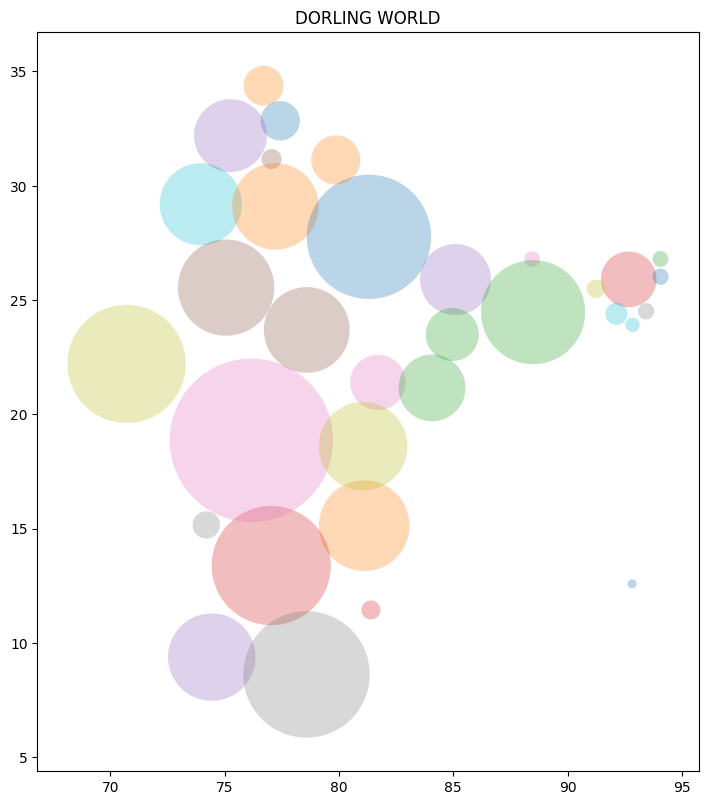

In [8]:
# DORLING Test
new_data = CartogramFramework_global(
    data        = data,
    # target_areas    = target_areas,
    fixed_points    = None,
    shape           = "circle",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),

    lambda_shape    = 0.1,   # small — circles form without needing shape pressure
    lambda_area     = 1.0,
    lambda_center   = 0.5,   # moderate centre fidelity keeps circles near geography
    lambda_topology = 1.0,

    gamma = 0.0,   # REQUIRED — pure E_circle
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,
    t_min   = 0.01,
    t_max   = 5.0,
    shape_deformation = 0.0,   # triggers make_circle()
)
plot_polys_data(new_data, title="DORLING WORLD", centroids=False, legend=False, target_centers=None, svg=True)

Contiguous mode 'original': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 3.66037


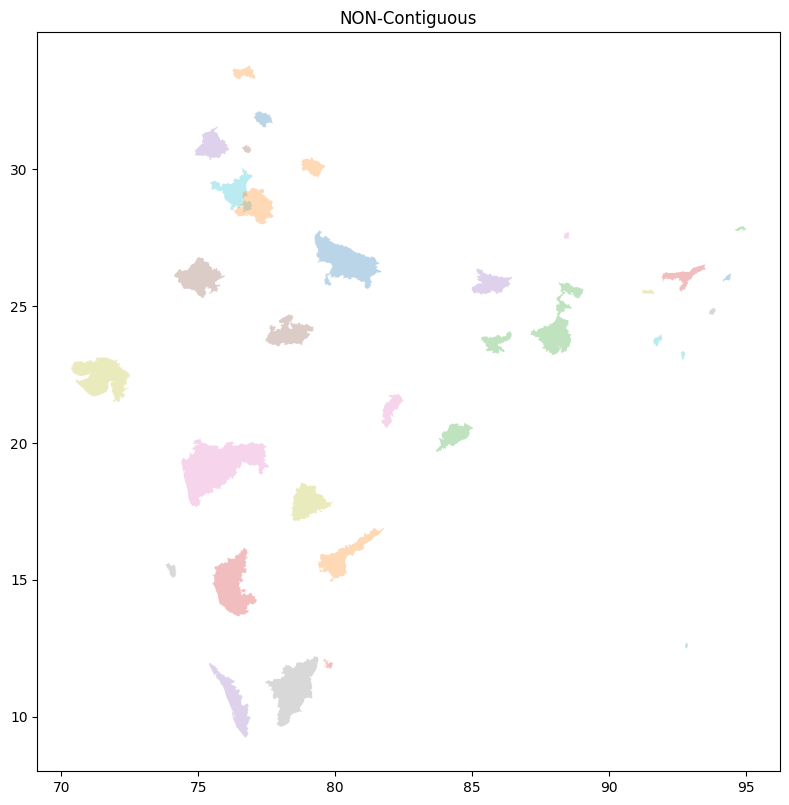

In [9]:
new_data = CartogramFramework_global(
    data=data,
    shape="original",

    target_centers=None,          # don't move the centroids yet

    neighboring_pairs=None,
    horizontal_pairs=None,
    vertical_pairs=None,
    shared_vertices_of_neighbors=None,
    soft_mean_scale=True,

    lambda_shape=0.0,             # let area scaling dominate for shrinkage
    lambda_area=1.0,              # keep the soft mean-scale / area target active
    lambda_center=0.0,
    lambda_topology=0.0,

    area_scale=0.1,

    gamma=1.0,
    beta=1.0,

    t_min=1e-8,
    t_max=10000.0,
)
plot_polys_data(new_data, title="NON-Contiguous", centroids=False, legend=False, target_centers=None)

Contiguous mode 'original': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 44773.7


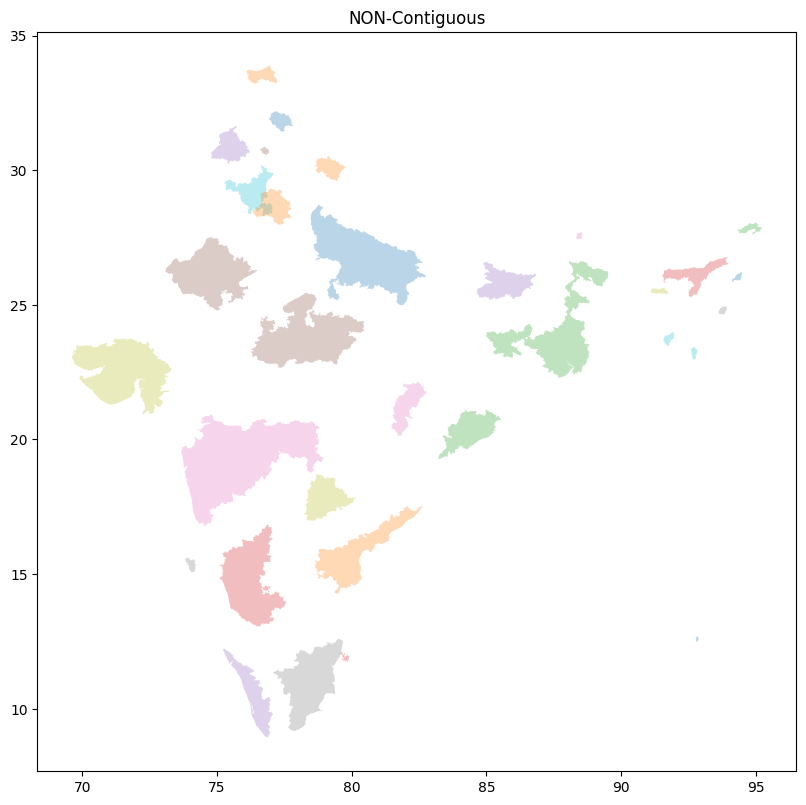

In [10]:
new_data = CartogramFramework_global(
    data         = data,
    # target_areas     = target_areas,
    fixed_points     = None,
    shape            = "original",
    target_centers   = target_positions,
    horizontal_pairs = None,   # no ordering — just scale in place
    vertical_pairs   = None,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = None,

    lambda_shape    = 1.0,
    lambda_area     = 1.0,
    lambda_center   = 0.5,   # moderate pull keeps regions near original position
    lambda_topology = 0.0,   # OFF — ordering was causing infeasibility

    area_scale = 0.1,

    gamma = 1.0,
    beta  = 1.0,
    t_min = 0.01,
    t_max = 25000.0,   # large — some regions may need to grow a lot
)
plot_polys_data(new_data, title="NON-Contiguous", centroids=False, legend=False, target_centers=None)

Contiguous mode 'contiguous': 2608 shared-vertex constraints added.


/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/src/core/CartogramFramework_data_maybe.py:1171: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob = cp.Problem(objective, constraints)
/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/src/core/CartogramFramework_data_maybe.py:1172: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob.solve(solver=cp.CLARABEL, verbose=False)


Status : optimal
Obj val: 3049.59


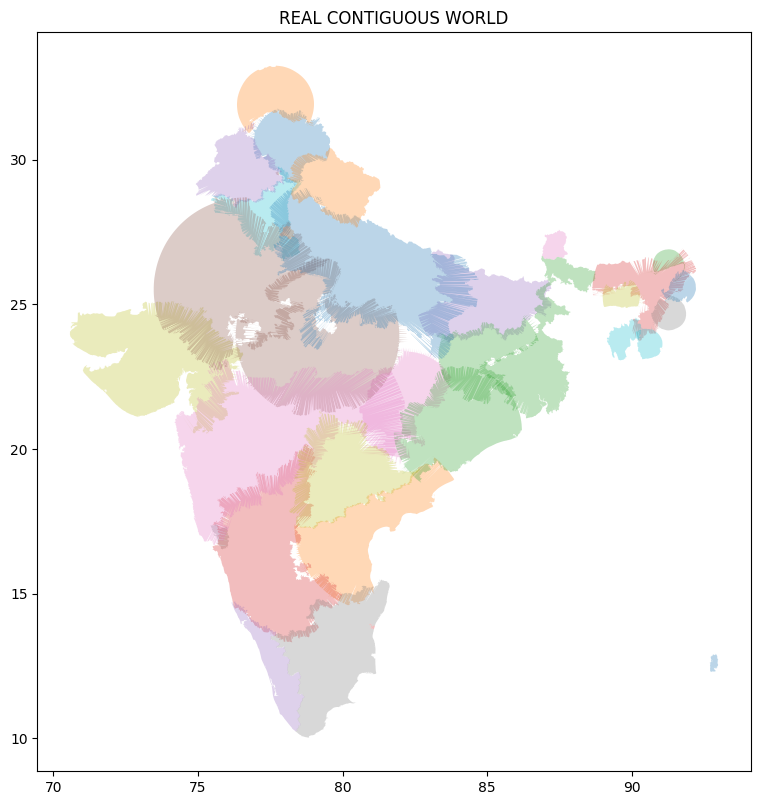

In [11]:
# Test with Cartogram Framework 0 without post processing
new_data = CartogramFramework_global(
    data        = data,
    fixed_points    = None,
    shape           = "contiguous",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,       # only for contiguous2 The higher the closer to contiguous
    soft_mean_scale   = True,       # Makes mean(t) = s soft not hard
    lambda_mean_scale = 1e-10,        # Weight of the hardness of soft_mean_scale. The higher the closer to soft_mean_scale = False
    t_min = 0.01,
    t_max = 1.5,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,
)
plot_polys_data(new_data, title="REAL CONTIGUOUS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

Contiguous mode 'contiguous2': 2608 shared-vertex penalty terms added.
Status : optimal
Obj val: 11948.5


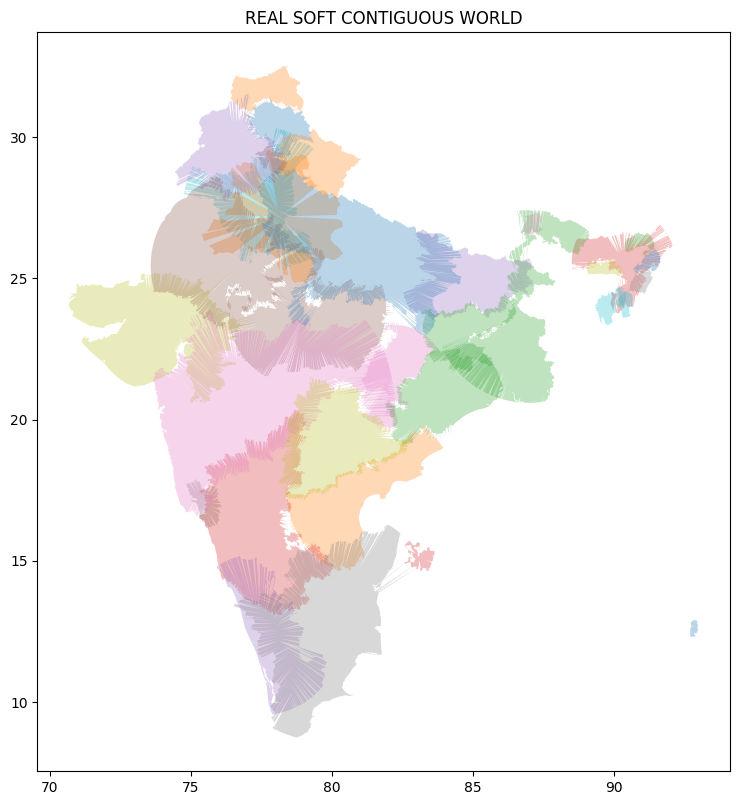

In [12]:
# Test with Cartogram Framework 0 without post processing
new_data = CartogramFramework_global(
    data        = data,
    # target_areas    = target_areas,
    fixed_points    = None,
    shape           = "contiguous2",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,       # only for contiguous2 The higher the closer to contiguous
    soft_mean_scale   = True,       # Makes mean(t) = s soft not hard
    lambda_mean_scale = 1e4,        # Weight of the hardness of soft_mean_scale. The higher the closer to soft_mean_scale = False
    t_min = 0.01,
    t_max = 15,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,
)
plot_polys_data(new_data, title="REAL SOFT CONTIGUOUS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

Contiguous mode 'contiguous2': 2608 shared-vertex penalty terms added.
Status : optimal
Obj val: 1.10215e+06


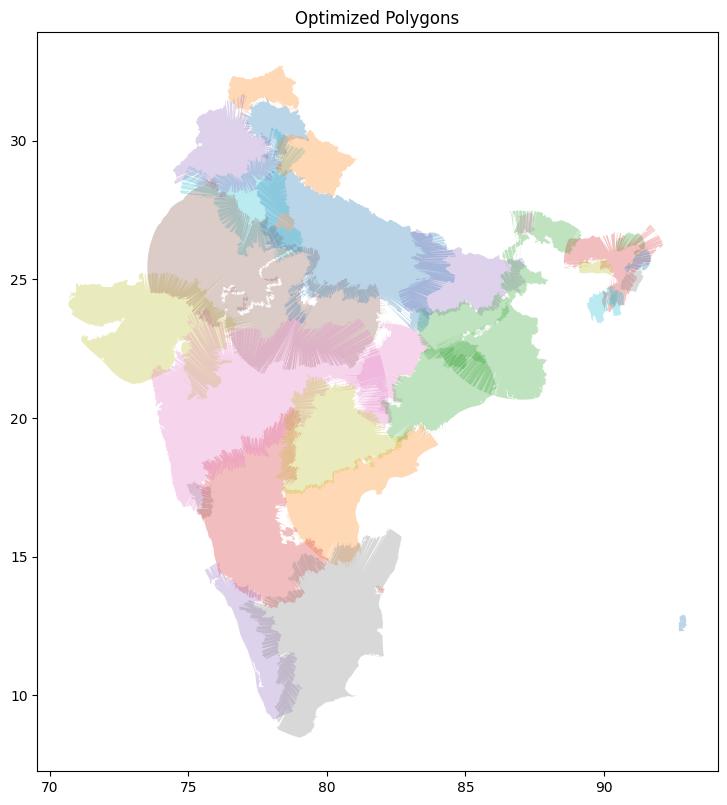

In [13]:
new_data = CartogramFramework_global(
    data        = data,
    # target_areas    = target_areas,
    fixed_points    = None,
    shape           = "contiguous2",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,
    soft_mean_scale   = True,
    lambda_mean_scale = 1e4,
    t_min = 0.01,
    t_max = 1.5,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,

    # ── Post-processing ───────────────────────────────────────────
    postprocess_contiguous  = False,     # flip to False to skip entirely
    postprocess_snap_method = "mean",   # midpoint snap on shared vertices
)
plot_polys_data(new_data, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

## Last Output from last meeting

Contiguous mode 'contiguous2': 11 shared-vertex penalty terms added.


/home/kuenem/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Status : optimal
Obj val: 1.10167e+06
Post-processing: snapping shared vertices (method='mean')


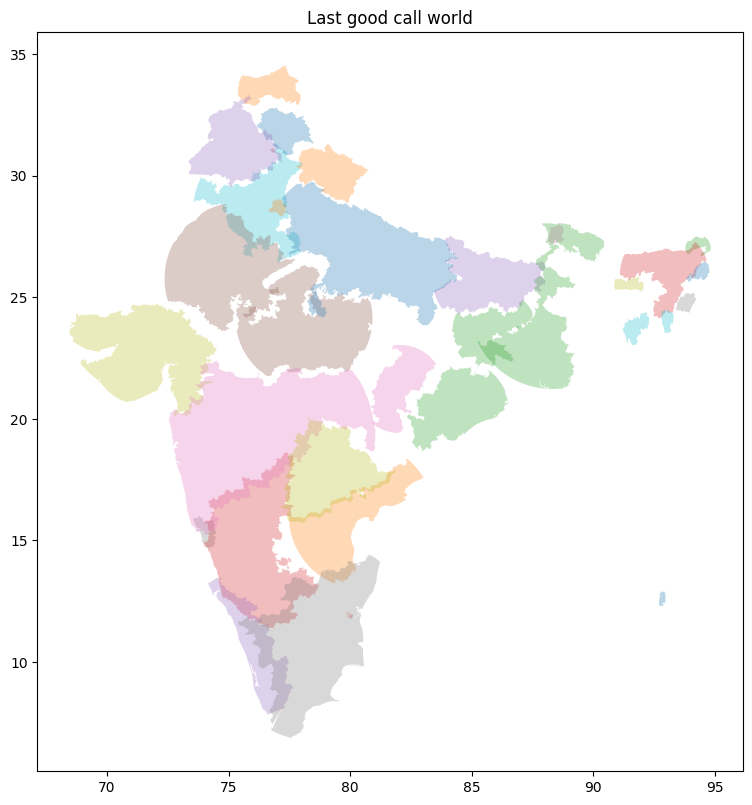

In [14]:
new_data = CartogramFramework_global(
    data        = data,
    # target_areas    = target_areas,
    fixed_points    = None,
    shape           = "contiguous2",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons, tolerance=10),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons, tolerance=10e10),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,
    soft_mean_scale   = True,
    lambda_mean_scale = 1e4,
    t_min = 0.01,
    t_max = 1.5,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,

    # ── Post-processing ───────────────────────────────────────────
    postprocess_contiguous  = True,     # flip to False to skip entirely
    postprocess_snap_method = "mean",   # midpoint snap on shared vertices
)
plot_polys_data(new_data, title="Last good call world", centroids=False, legend=False, target_centers=None, svg=True)

Contiguous mode 'contiguous2': 2608 shared-vertex penalty terms added.
Status : optimal
Obj val: 1.10215e+06


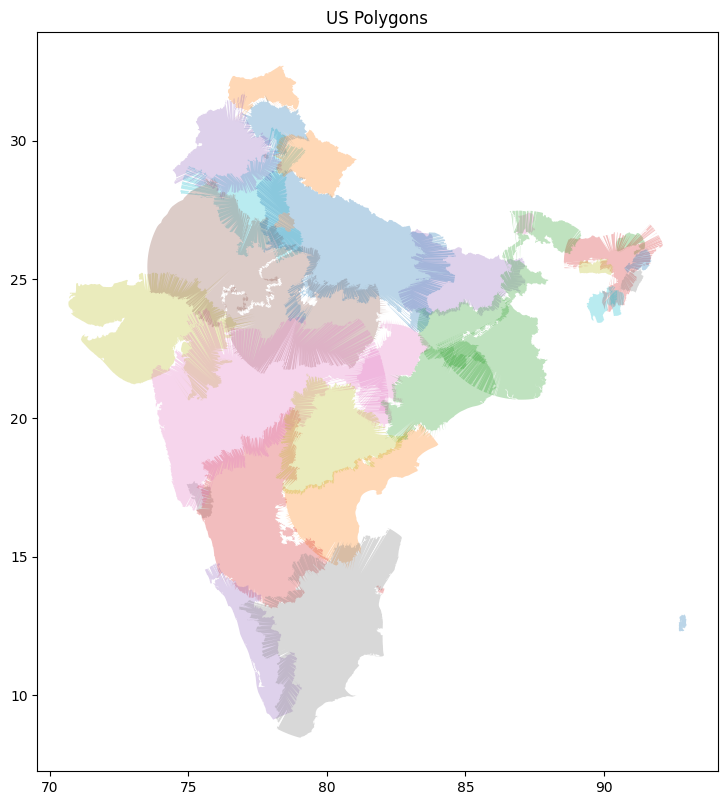

In [15]:
new_data = CartogramFramework_global(
    data        = data,
    # target_areas    = target_areas,
    fixed_points    = None,
    shape           = "contiguous2",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,
    soft_mean_scale   = True,
    lambda_mean_scale = 1e4,
    t_min = 0.01,
    t_max = 1.5,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,

    # ── Post-processing ───────────────────────────────────────────
    postprocess_contiguous  = False,     # flip to False to skip entirely
    postprocess_snap_method = "mean",   # midpoint snap on shared vertices
)
plot_polys_data(new_data, title="US Polygons", centroids=False, legend=False, target_centers=None)

In [16]:
base_path = "/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/"
path = os.path.join(base_path, "data/geojson/contiguous/world/world.geojson")
path = os.path.join(base_path, "R/world_cartogram_2010_ncont.geojson")
path = os.path.join(base_path, "R/world_cartogram_2010_dorling.geojson")
path = os.path.join(base_path, "R/world_cartogram_2010_cont.geojson")

In [17]:
polygons, target_areas, target_positions, names, centroid = get_polygon_data(path, exclude=None)
# print(polygons)
plot_polys(polygons, title="COntiguous Polygons", legend=False)

TypeError: get_polygon_data() missing 1 required positional argument: 'data'

In [ ]:
def cartographic_error(df, polygons, names, index=None):
    if index is not None:
        df = df.set_index("ISO_CODE")
    total_target = 0
    total_area = 0
    normalized_area = []
    error_cartographic = []

    for polygon, name in zip(polygons, names):
        target = df.loc[name, "Population (people)"]
        total_target += target
        total_area += polygon_areanp(polygon)

    c = total_area/total_target
    
    for polygon, name in zip(polygons, names):
        target = df.loc[name, "Population (people)"]
        norm_area = polygon_areanp(polygon)/c
        normalized_area.append(norm_area)

        e_cartographic = abs(norm_area - target) / norm_area
        error_cartographic.append(e_cartographic)

    e_c = pd.Series(error_cartographic)
    print(e_c.describe())

    return error_cartographic


In [ ]:
df = pd.read_csv(os.path.join(base_path, "data/statistics/contiguous/world/world.csv"))
df = df.set_index("ISO_CODE")

In [ ]:
total_target = 0
total_area = 0
for polygon, name in zip(polygons, names):
    poly = Polygon(polygon)
    target = df.loc[name, "Population (people)"]
    total_target += target
    total_area += poly.area
    # print(f"Polygon: {name}, Target: {target}, Area: {polygon_areanp(polygon):.2f}, Shapely Area: {poly.area:.2f}")

In [ ]:
c = total_area/total_target
normalized_area = []
error_cartographic = []
for polygon, name in zip(polygons, names):
    target = df.loc[name, "Population (people)"]
    norm_area = polygon_areanp(polygon)/c
    normalized_area.append(norm_area)

    e_cartographic = abs(norm_area - target) / norm_area
    error_cartographic.append(e_cartographic)
print(error_cartographic)

In [ ]:
for polygon, name in zip(polygons, names):
    target = df.loc[name, "Population (people)"]
    poly = Polygon(polygon)
    print(f"Error: {target/total_target - poly.area/total_area:.2f}")